In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from tqdm.autonotebook import tqdm
from matplotlib import rcParams
import numpy as np
import gradio as gr
import numpy as np
import plotly.graph_objects as go

class HHModel():
    def __init__(self, dt = 0.01, iter = 10000):
        self.gK_max = 0.36 # max conductance of K channel
        self.gNa_max = 1.20 # max condutance of Na channel
        self.gl = 0.003 # Leaky channel conductance
        self.E_Na = 50 # Nernst potential of Na channel
        self.E_K = -77 # Nernst potential of K channel
        self.E_l = -54.387 # Nernst potential of leaky channel
        self.C = 0.01 # Membrane conductance
        self.v_monitor = [] # Monitor to append all the voltage values
        self.gNa_monitor = [] # Monitor to append all the Na conductance values
        self.gK_monitor = [] # Monitor to append all the K conductance values
        self.m_monitor = [] # Monitor to append all the values of gating variable m
        self.n_monitor = [] # Monitor to append all the values of gating variable n
        self.h_monitor = [] # Monitor to append all the values of gating variable h
        self.dt = dt
        self.iter = iter

    def solve(self, I_app: float):
        '''
        Computes the voltage using Hodgkin Huxeley model
        -------------------------------------------------
        Args:
            I_app: External current (micro amperes)
            dt: Step length for Euler method. Default = 0.01 ms
            iter: Number of iterations. Default = 10000
        Returns:
            v_monitor: voltage
            m: Gating variable
            n: Gating variable
            h: Gating variable
            gNa: Conductance of Na channel
            gK: Conductance of K channel
        --------------------------------------------------
        '''
        v = -64.9964
        m = 0.0530
        h = 0.5960
        n = 0.3177
        dt = self.dt
        iter = self.iter
        self.gK_monitor = []
        self.gNa_monitor = []
        self.m_monitor = []
        self.n_monitor = []
        self.h_monitor = []
        self.v_monitor = []
        for i in range(iter):
            gNa = self.gNa_max * (m**3) * h
            gK = self.gK_max * n**4


            dv = (-gNa * (v - self.E_Na) - gK * (v - self.E_K) - self.gl *(v- self.E_l) + I_app)/self.C
            v = v + dt* dv

            alpha_m = 0.1 * (v + 40) / (1- np.exp(-(v + 40)/10))
            beta_m = 4 * np.exp(-0.0556 * (v + 65))
            alpha_h = 0.07 * (np.exp(-0.05 *(v + 65)))
            beta_h = 1/(1 + np.exp(-0.1 * (v + 35)))
            alpha_n = 0.01 * (v + 55)/(1 - np.exp(-(v + 55)/10))
            beta_n = 0.125 * np.exp(-(v + 65)/80)

            dm = alpha_m * (1 - m) - beta_m * m
            dn = alpha_n * (1 - n) - beta_n * n
            dh = alpha_h * (1 - h) - beta_h * h

            m = m + dt * dm
            n = n + dt * dn
            h = h + dt * dh

            self.v_monitor.append(v)
            self.m_monitor.append(m)
            self.n_monitor.append(n)
            self.h_monitor.append(h)
            self.gNa_monitor.append(gNa)
            self.gK_monitor.append(gK)

        return self.v_monitor, self.m_monitor, self.n_monitor, self.h_monitor, self.gNa_monitor, self.gK_monitor



def run_hh_simulation(I_app, duration, dt, show_vars):
    # Convert duration (ms) to number of iterations
    iter_count = int(duration / dt)

    # Instantiate model
    model = HHModel(dt=dt, iter=iter_count)

    # Run simulation
    v, m, n, h, gNa, gK = model.solve(I_app)

    # Create time vector
    t = np.arange(0, duration, dt)

    # --- Voltage plot ---
    fig_v = go.Figure()
    if "Voltage" in show_vars:
        fig_v.add_trace(go.Scatter(x=t, y=v, mode='lines', name="Voltage (mV)", line=dict(color="black")))
    fig_v.update_layout(
        title="Membrane Voltage (mV)",
        xaxis_title="Time (ms)",
        yaxis_title="Voltage (mV)",
        template="plotly_white",
        height=400,
    )

    # --- Gating variables plot ---
    fig_gate = go.Figure()
    if any(x in show_vars for x in ["m", "n", "h"]):
        if "m" in show_vars:
            fig_gate.add_trace(go.Scatter(x=t, y=m, mode='lines', name="m (Na activation)"))
        if "n" in show_vars:
            fig_gate.add_trace(go.Scatter(x=t, y=n, mode='lines', name="n (K activation)"))
        if "h" in show_vars:
            fig_gate.add_trace(go.Scatter(x=t, y=h, mode='lines', name="h (Na inactivation)"))
    fig_gate.update_layout(
        title="Gating Variables (m, n, h)",
        xaxis_title="Time (ms)",
        yaxis_title="Probability",
        template="plotly_white",
        height=400,
    )

    # --- Conductance plot ---
    fig_cond = go.Figure()
    if any(x in show_vars for x in ["gNa", "gK"]):
        if "gNa" in show_vars:
            fig_cond.add_trace(go.Scatter(x=t, y=gNa, mode='lines', name="gNa (Na conductance)"))
        if "gK" in show_vars:
            fig_cond.add_trace(go.Scatter(x=t, y=gK, mode='lines', name="gK (K conductance)"))
    fig_cond.update_layout(
        title="Ion Channel Conductances (mS/cm²)",
        xaxis_title="Time (ms)",
        yaxis_title="Conductance",
        template="plotly_white",
        height=400,
    )

    return fig_v, fig_gate, fig_cond


with gr.Blocks(title="Hodgkin-Huxley Neuron Simulator") as demo:
    gr.Markdown("""
    # 🧠 Hodgkin-Huxley Neuron Simulator
    This interactive demo simulates the **Hodgkin-Huxley model**, a foundational model
    describing how neurons generate electrical impulses (action potentials).

    Adjust the input parameters and explore how the neuron's membrane voltage
    and ion channel dynamics change over time.
    """)

    with gr.Row():
        I_app = gr.Slider(0, 1, value=0.47, step=0.05, label="Applied Current (µA)")
        duration = gr.Slider(100, 5000, value=100, step=100, label="Duration (ms)")
        dt = gr.Slider(0.001, 0.1, value=0.01, step=0.001, label="Time Step (ms)")

    show_vars = gr.CheckboxGroup(
        ["Voltage", "m", "n", "h", "gNa", "gK"],
        value=["Voltage"],
        label="Select variables to visualize"
    )

    run_button = gr.Button("Run Simulation 🚀")


    with gr.Row():
        output_v = gr.Plot(label="Voltage Trace")
    with gr.Row():
        output_gates = gr.Plot(label="Gating Variables (m, n, h)")
    with gr.Row():
        output_cond = gr.Plot(label="Conductances (gNa, gK)")

    run_button.click(
        fn=run_hh_simulation,
        inputs=[I_app, duration, dt, show_vars],
        outputs=[output_v, output_gates, output_cond],
    )

    gr.Markdown("""
    ---
    **Tips for exploration:**
    - Try increasing *I_app* to see repetitive firing.
    - Reduce *I_app* to observe subthreshold responses.
    - Experiment with smaller *dt* for higher numerical accuracy.
    """)



def launch_HH_app():
    demo.launch(share = True)

/tmp/ipykernel_2765/2863584235.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from tqdm.autonotebook import tqdm
from matplotlib import rcParams
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
rcParams["font.size"] = 12
rcParams["axes.spines.top"] =  False
rcParams["axes.spines.right"] = False

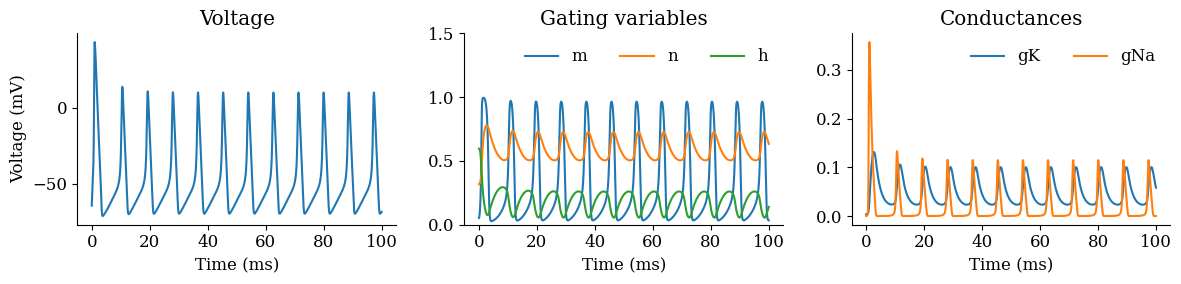

In [3]:
HH = HHModel(dt = 0.01, iter = 10000) # dt is in ms
v, m, n, h, gNa, gK = HH.solve(I_app = 0.47)
time = np.linspace(0, 100, 10000)

plt.figure(figsize=(12, 3))
plt.subplot(1,3,1)
plt.plot(time, v)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
# plt.xlim(0,100)
plt.title("Voltage")

plt.subplot(1,3,2)
plt.plot(time, m, label = 'm')
plt.plot(time, n, label = 'n')
plt.plot(time, h, label = 'h')
plt.xlabel("Time (ms)")
plt.ylim(0,1.5)
# plt.xlim(0,100)
plt.title("Gating variables")
plt.legend(ncol = 3, frameon = False)
plt.subplot(1,3,3)
plt.plot(time, gK, label = 'gK')
plt.plot(time, gNa, label = 'gNa')
plt.xlabel("Time (ms)")
plt.title("Conductances")
# plt.xlim(0,100)
plt.legend(frameon = False, ncol = 2)
plt.tight_layout()
plt.show()


In [4]:
def spike_count(voltage)-> np.ndarray:
    '''
    Computes Location of peaks in the given voltage np.ndarray
    -----------------------------------------------------------
    Args:
        Voltage: 1D array of voltage wrt time
    Returns:
        peaks: np.ndarray of the spike indexes
    -----------------------------------------------------------
    '''
    voltage = np.array(voltage)
    thres_Na = 10 # Cross value to count as a peak
    peaks, _ = signal.find_peaks(voltage, height= thres_Na)
    return peaks


def frequency(peaks_data: np.ndarray, dt, iter) -> float:
    '''
    Function to compute frequency of peaks
    ----------------------------------------------------------------
    Args:
        peaks_data: 1D array of location of peaks in the voltage spikes data

    Returns:
        freq: frequency of the spikes
    -----------------------------------------------------------------
    '''
    num_peaks = peaks_data.shape[0]
    freq = (num_peaks * 10**3)/(dt * iter)
    return freq


In [5]:
# Plotting frequency Vs External current
dt = 0.01
iter = 100000
I_ext = np.linspace(0 ,0.7 ,50) # Array of ext currents to compute frequency
freq_monitor = np.zeros(len(I_ext))

for i in tqdm(range(len(I_ext))):
    HH = HHModel(dt = dt, iter = iter)
    v, m, n, h, gNa, gK = HH.solve(I_app = I_ext[i])
    peaks =spike_count(v)
    freq = frequency(peaks, dt, iter)
    freq_monitor[i] = freq


  0%|          | 0/50 [00:00<?, ?it/s]

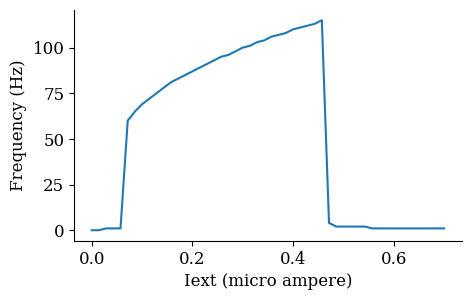

In [6]:
# Plotting Iext Vs Frequency
plt.figure(figsize = (5,3))
plt.xlabel('Iext (micro ampere)')
plt.ylabel('Frequency (Hz)')
plt.plot(I_ext, freq_monitor)

In [7]:
launch_HH_app()

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0744fbd0e389fb2ba5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
